**PCA:**

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Import the sample containing also the original labels
df = pd.read_csv('/content/sample_with_labels.csv')
df.fillna(0, inplace=True)

# Temporarily remove 'user_uid'
features_df = df.drop(columns=['user_uid', 'label_pred_desc'])

features_df = pd.DataFrame(features_df, columns=df.columns.drop(['user_uid', 'label_pred_desc']))


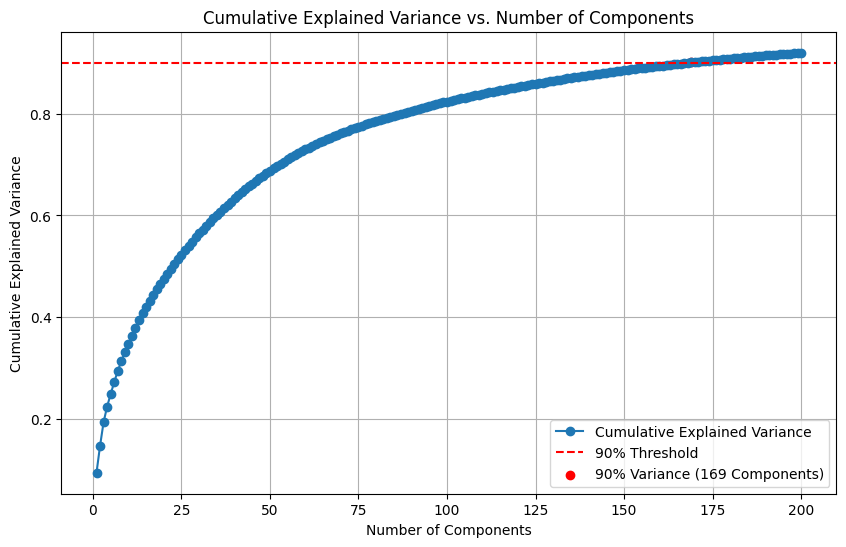

Number of components to reach 90% variance: 169
     Number of Components  Cumulative Explained Variance
0                       1                       0.095133
1                       2                       0.147870
2                       3                       0.194479
3                       4                       0.224988
4                       5                       0.249598
..                    ...                            ...
195                   196                       0.917329
196                   197                       0.917862
197                   198                       0.918387
198                   199                       0.918908
199                   200                       0.919426

[200 rows x 2 columns]


In [3]:
# PCA computed using the rule of thumb of retaining more than 90% of explained variance

# Set the maximum number of components
max_k = 200

# Initialize PCA with the maximum number of components
pca = PCA(n_components=max_k)

# Fit PCA to the sample data
pca_model = pca.fit(features_df)

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(pca_model.explained_variance_ratio_)

# Create a DataFrame with the number of components and explained variance
explained_variance_df = pd.DataFrame({
    'Number of Components': range(1, max_k + 1),
    'Cumulative Explained Variance': cumulative_explained_variance
})

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(
    explained_variance_df['Number of Components'],
    explained_variance_df['Cumulative Explained Variance'],
    marker='o', linestyle='-', label='Cumulative Explained Variance'
)

# Add a horizontal line at the 90% threshold
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')

# Highlight the point where variance exceeds 90%
components_90 = explained_variance_df[
    explained_variance_df['Cumulative Explained Variance'] >= 0.90
].iloc[0]
plt.scatter(components_90['Number of Components'], components_90['Cumulative Explained Variance'],
            color='red', label=f'90% Variance ({int(components_90["Number of Components"])} Components)')

# Add labels and title
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.legend()
plt.grid(True)
plt.show()

# Print the DataFrame and the number of components for 90% explained variance
print(f"Number of components to reach 90% variance: {int(components_90['Number of Components'])}")
print(explained_variance_df)

In [ ]:
# Initialize PCA computed with the rule of thumb
pca = PCA(n_components=169)
principal_components = pca.fit_transform(features_df)

# Store the principal components in a DataFrame
PCA_rule_of_thumb = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(169)])
PCA_rule_of_thumb['user_uid'] = df['user_uid']
PCA_rule_of_thumb['original_labels'] = df['label_pred_desc']
PCA_rule_of_thumb.to_csv('PCA_rule_of_thumb.csv', index=False)

Number of components to retain based on parallel analysis: 71
Number of components to retain based on Kaiser criterion: 90


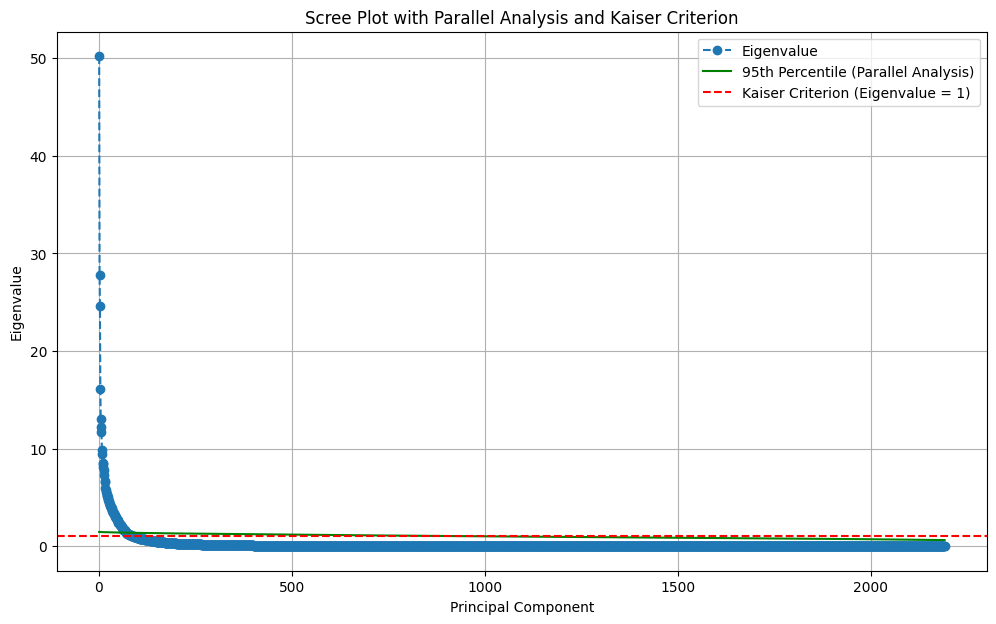

In [ ]:
# Scree plot with Kaiser criterion and parallel analysis

# Load the sample dataset
df = pd.read_csv('/content/sample_with_labels.csv')
df.fillna(0, inplace=True)

# Temporarily remove 'user_uid'
features_df = df.drop(columns=['user_uid', 'label_pred_desc'])

features_df = pd.DataFrame(features_df, columns=df.columns.drop(['user_uid', 'label_pred_desc']))

# Set the maximum number of components
max_k = 2192

# Initialize PCA with the maximum number of components
pca = PCA(n_components=max_k)

# Fit PCA to the sample data
pca_model = pca.fit(features_df)

# Access eigenvalues (these are the variance explained by each component)
eigenvalues = pca_model.explained_variance_

# Parallel Analysis Implementation

def parallel_analysis(data, n_simulations=100, random_seed=42):
    """
    Perform parallel analysis to determine the number of components to retain in PCA.

    Parameters:
        data (numpy.ndarray): The data matrix (rows: observations, columns: variables).
        n_simulations (int): Number of random datasets to generate for comparison.
        random_seed (int): Seed for reproducibility of random number generation.

    Returns:
        random_threshold (numpy.ndarray): 95th percentile of random data eigenvalues.
    """
    np.random.seed(random_seed)
    n_obs, n_vars = data.shape

    # Generate random datasets and compute eigenvalues
    eigenvalues_random = np.zeros((n_simulations, n_vars))
    for i in range(n_simulations):
        random_data = np.random.normal(size=(n_obs, n_vars))
        random_pca = PCA(n_components=n_vars)
        random_pca.fit(random_data)
        eigenvalues_random[i, :] = random_pca.explained_variance_

    # Calculate the 95th percentile of eigenvalues from random data
    random_threshold = np.percentile(eigenvalues_random, 95, axis=0)
    return random_threshold

# Perform parallel analysis
random_threshold = parallel_analysis(features_df.values)

# Determine the number of components to retain according to Parallel Analysis
n_components_parallel = np.sum(eigenvalues > random_threshold)

# Determine the number of components to retain according to the Kaiser Criterion
n_components_kaiser = np.sum(eigenvalues > 1)

print(f"Number of components to retain based on parallel analysis: {n_components_parallel}")
print(f"Number of components to retain based on Kaiser criterion: {n_components_kaiser}")

# Visualization

# Create a scree plot with eigenvalues on the y-axis
plt.figure(figsize=(12, 7))
plt.plot(range(1, max_k + 1), eigenvalues, marker='o', linestyle='--', label='Eigenvalue')
plt.plot(range(1, max_k + 1), random_threshold, color='g', linestyle='-', label='95th Percentile (Parallel Analysis)')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot with Parallel Analysis and Kaiser Criterion')
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion (Eigenvalue = 1)')  # Highlight the Kaiser Criterion
plt.legend()
plt.grid(True)
plt.show()

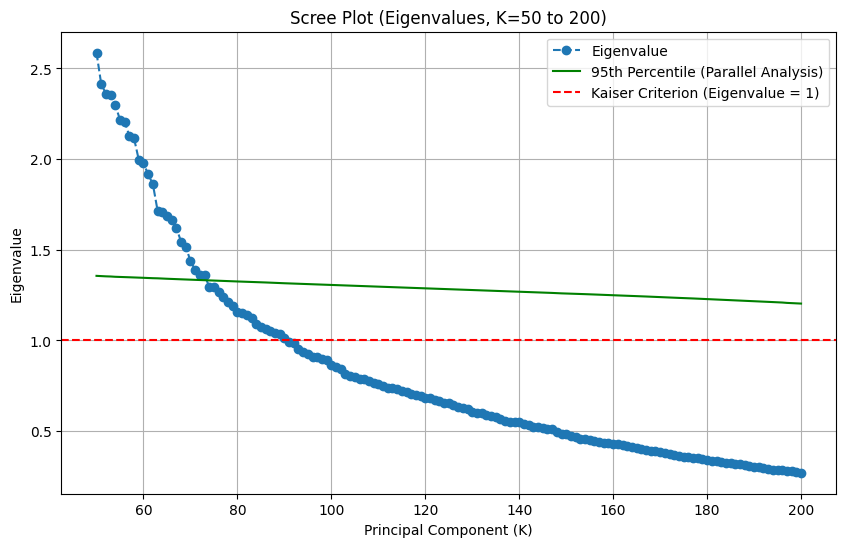

In [ ]:
# Screeplot detail
# Set the maximum number of components
max_k = 200

# Initialize PCA with the maximum number of components
pca = PCA(n_components=max_k)

# Fit PCA to the sample data
pca_model = pca.fit(features_df)

# Access eigenvalues (these are the variance explained by each component)
eigenvalues = pca_model.explained_variance_

# ------------------ Parallel Analysis Implementation ------------------

def parallel_analysis(data, n_components, n_simulations=50, random_seed=42):
    """
    Perform parallel analysis to determine the number of components to retain in PCA.

    Parameters:
        data (numpy.ndarray): The data matrix (rows: observations, columns: variables).
        n_components (int): Number of PCA components to compute.
        n_simulations (int): Number of random datasets to generate for comparison.
        random_seed (int): Seed for reproducibility of random number generation.

    Returns:
        random_threshold (numpy.ndarray): 95th percentile of random data eigenvalues.
    """
    np.random.seed(random_seed)
    n_obs, n_vars = data.shape

    # Generate random datasets and compute eigenvalues
    eigenvalues_random = np.zeros((n_simulations, n_components))
    for i in range(n_simulations):
        random_data = np.random.normal(size=(n_obs, n_vars))
        random_pca = PCA(n_components=n_components)  # Use the same number of components as the real data PCA
        random_pca.fit(random_data)
        eigenvalues_random[i, :] = random_pca.explained_variance_

    # Calculate the 95th percentile of eigenvalues from random data
    random_threshold = np.percentile(eigenvalues_random, 95, axis=0)
    return random_threshold

# Perform parallel analysis with 200 components (same as the real data PCA)
random_threshold = parallel_analysis(features_df.values, n_components=max_k, n_simulations=50)

# Determine the number of components to retain according to Parallel Analysis
n_components_parallel = np.sum(eigenvalues > random_threshold)

# ------------------ Kaiser Criterion ------------------

# Determine the number of components to retain based on the Kaiser criterion
n_components_kaiser = np.sum(eigenvalues >= 1)

# ------------------ Filtered Scree Plot ------------------

# Filter for K values between 50 and 200
k_start = 50
k_end = 200
filtered_eigenvalues = eigenvalues[k_start - 1:k_end]  # Python uses 0-based indexing
filtered_random_threshold = random_threshold[k_start - 1:k_end]  # Filter parallel analysis threshold
filtered_indices = range(k_start, k_end + 1)

# Create a scree plot with filtered eigenvalues
plt.figure(figsize=(10, 6))
plt.plot(filtered_indices, filtered_eigenvalues, marker='o', linestyle='--', label='Eigenvalue')
plt.plot(filtered_indices, filtered_random_threshold, color='g', linestyle='-', label='95th Percentile (Parallel Analysis)')
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion (Eigenvalue = 1)')  # Highlight the Kaiser Criterion
plt.xlabel('Principal Component (K)')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot (Eigenvalues, K=50 to 200)')
plt.legend()
plt.grid(True)
plt.show()





In [ ]:
# ------------------ Print Results ------------------

# Print the number of components to retain based on Parallel Analysis
print(f"Number of components to retain based on Parallel Analysis: {n_components_parallel}")

# Print the number of components to retain based on the Kaiser Criterion
print(f"Number of components to retain based on the Kaiser Criterion: {n_components_kaiser}")

Number of components to retain based on Parallel Analysis: 73
Number of components to retain based on the Kaiser Criterion: 90


In [ ]:
# Initialize PCA computed with the Kaiser criterion
pca = PCA(n_components=90)
principal_components = pca.fit_transform(features_df)

# Store the principal components in a DataFrame
PCA_kaiser = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(90)])
PCA_kaiser['user_uid'] = df['user_uid']
PCA_kaiser['original_labels'] = df['label_pred_desc']
PCA_kaiser.to_csv('PCA_kaiser.csv', index=False)

In [ ]:
# Initialize PCA computed with the parallel analysis
pca = PCA(n_components=71)
principal_components = pca.fit_transform(features_df)

# Store the principal components in a DataFrame
PCA_parallel = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(71)])
PCA_parallel['user_uid'] = df['user_uid']
PCA_parallel['original_labels'] = df['label_pred_desc']
PCA_parallel.to_csv('PCA_parallel.csv', index=False)

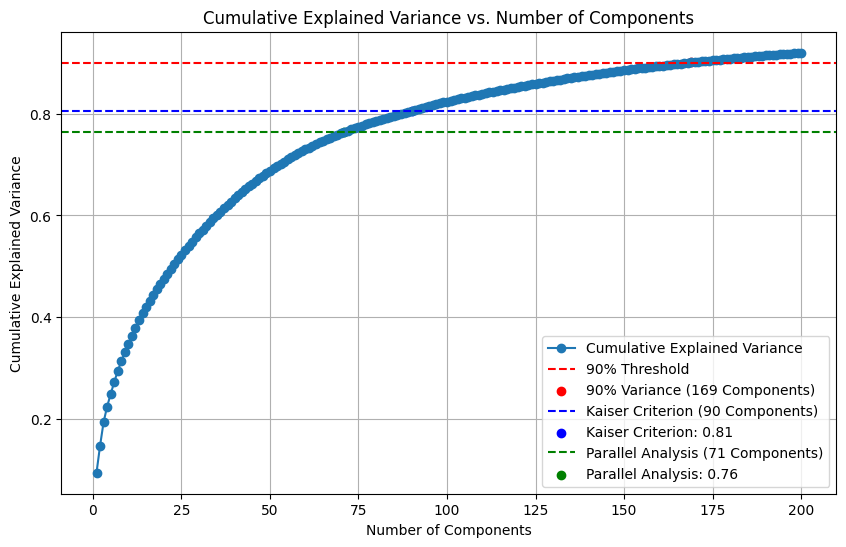

Cumulative explained variance for 90 components (Kaiser): 0.81
Cumulative explained variance for 71 components (Parallel Analysis): 0.76


In [4]:
# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(
    explained_variance_df['Number of Components'],
    explained_variance_df['Cumulative Explained Variance'],
    marker='o', linestyle='-', label='Cumulative Explained Variance'
)

# Add a horizontal line at the 90% threshold
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')

# Highlight the point where variance exceeds 90%
components_90 = explained_variance_df[
    explained_variance_df['Cumulative Explained Variance'] >= 0.90
].iloc[0]
plt.scatter(components_90['Number of Components'], components_90['Cumulative Explained Variance'],
            color='red', label=f'90% Variance ({int(components_90["Number of Components"])} Components)')

# Add a horizontal line for the Kaiser criterion (90 components)
explained_variance_kaiser = cumulative_explained_variance[89]  # Index 89 corresponds to the 90th component
plt.axhline(y=explained_variance_kaiser, color='blue', linestyle='--',
            label=f'Kaiser Criterion (90 Components)')
plt.scatter(90, explained_variance_kaiser, color='blue',
            label=f'Kaiser Criterion: {explained_variance_kaiser:.2f}')

# Add a horizontal line for the parallel analysis (71 components)
explained_variance_parallel = cumulative_explained_variance[70]  # Index 70 corresponds to the 71st component
plt.axhline(y=explained_variance_parallel, color='green', linestyle='--',
            label=f'Parallel Analysis (71 Components)')
plt.scatter(71, explained_variance_parallel, color='green',
            label=f'Parallel Analysis: {explained_variance_parallel:.2f}')

# Add labels and title
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.legend()
plt.grid(True)
plt.show()

# Print the values for Kaiser criterion and parallel analysis
print(f"Cumulative explained variance for 90 components (Kaiser): {explained_variance_kaiser:.2f}")
print(f"Cumulative explained variance for 71 components (Parallel Analysis): {explained_variance_parallel:.2f}")
